# Brain Tumor MRI Image Classification
### EDA → CNN → Transfer Learning → Fine-Tuning → Evaluation → Grad-CAM → Streamlit

**Project objective:** classify brain MRI images into four classes:

- Glioma
- Meningioma
- No Tumor
- Pituitary

This notebook is designed for **Kaggle** and follows the project brief supplied with the dataset: data understanding, preprocessing, augmentation, a custom CNN, transfer learning, model evaluation, model comparison, and Streamlit deployment.

> **Medical-use note:** This is an educational image-classification prototype, not a clinical diagnostic system. Model confidence is not the same as clinical probability or diagnostic certainty.

# GitHub Link: https://github.com/rahulg2527-source/Brain-Tumor-MRI-Image-Classification.git
                  

## 1. Imports and configuration

The notebook uses TensorFlow/Keras for deep learning, scikit-learn for evaluation, and Matplotlib/Seaborn for visualization.

In [1]:
import os
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: []


2026-10-01 05:52:45.347117: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Locate the dataset automatically

Your uploaded archive contains the directory structure `Tumour/train`, `Tumour/valid`, and `Tumour/test`.

On Kaggle, upload the extracted **Tumour** folder as a Dataset, then attach that Dataset to the notebook.

The following cell searches `/kaggle/input` so you do not have to guess the dataset slug.

In [2]:
KAGGLE_INPUT = Path("/kaggle/input/datasets/sonug2527/brain-tumor-mri")

def find_tumour_root(base_dir=KAGGLE_INPUT):
    candidates = []
    if base_dir.exists():
        for p in base_dir.rglob("Tumour"):
            if (p / "train").is_dir() and (p / "valid").is_dir() and (p / "test").is_dir():
                candidates.append(p)
    if not candidates:
        raise FileNotFoundError(
            "Could not find a folder containing Tumour/train, Tumour/valid and Tumour/test. "
            "Attach your Kaggle Dataset first."
        )
    return candidates[0]

DATA_ROOT = find_tumour_root()
TRAIN_DIR = DATA_ROOT / "train"
VALID_DIR = DATA_ROOT / "valid"
TEST_DIR = DATA_ROOT / "test"

print("Dataset root:", DATA_ROOT)
print("Train:", TRAIN_DIR)
print("Valid:", VALID_DIR)
print("Test :", TEST_DIR)

Dataset root: /kaggle/input/datasets/sonug2527/brain-tumor-mri/Tumour-20260930T062410Z-1-001/Tumour
Train: /kaggle/input/datasets/sonug2527/brain-tumor-mri/Tumour-20260930T062410Z-1-001/Tumour/train
Valid: /kaggle/input/datasets/sonug2527/brain-tumor-mri/Tumour-20260930T062410Z-1-001/Tumour/valid
Test : /kaggle/input/datasets/sonug2527/brain-tumor-mri/Tumour-20260930T062410Z-1-001/Tumour/test


## 3. Dataset audit

The supplied dataset README states that there are 2,443 MRI images split into 1,695 training, 502 validation, and 246 test images, across four classes. The notebook recomputes these counts directly from the folders so the analysis is reproducible.

In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_by_class(split_dir):
    rows = []
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        count = sum(1 for p in class_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
        rows.append({"Class": class_dir.name, "Count": count})
    return pd.DataFrame(rows)

train_counts = count_images_by_class(TRAIN_DIR)
valid_counts = count_images_by_class(VALID_DIR)
test_counts = count_images_by_class(TEST_DIR)

display(train_counts)
display(valid_counts)
display(test_counts)

print("Total train:", train_counts["Count"].sum())
print("Total valid:", valid_counts["Count"].sum())
print("Total test :", test_counts["Count"].sum())
print("Overall    :", train_counts["Count"].sum() + valid_counts["Count"].sum() + test_counts["Count"].sum())

,Class,Count
0,glioma,564
1,meningioma,358
2,no_tumor,335
3,pituitary,438


,Class,Count
0,glioma,161
1,meningioma,124
2,no_tumor,99
3,pituitary,118


,Class,Count
0,glioma,80
1,meningioma,63
2,no_tumor,49
3,pituitary,54


Total train: 1695
Total valid: 502
Total test : 246
Overall    : 2443


## 4. Class distribution visualization

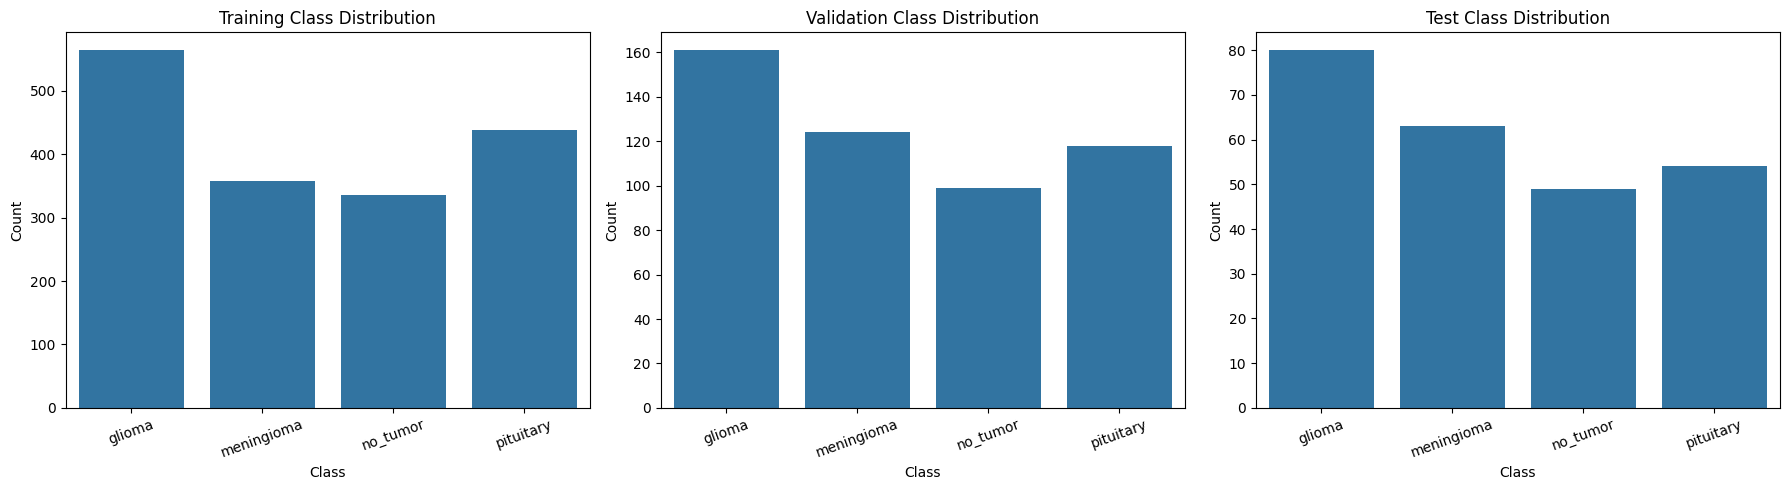

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=train_counts, x="Class", y="Count", ax=axes[0])
axes[0].set_title("Training Class Distribution")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=valid_counts, x="Class", y="Count", ax=axes[1])
axes[1].set_title("Validation Class Distribution")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=test_counts, x="Class", y="Count", ax=axes[2])
axes[2].set_title("Test Class Distribution")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 5. Preview MRI images

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


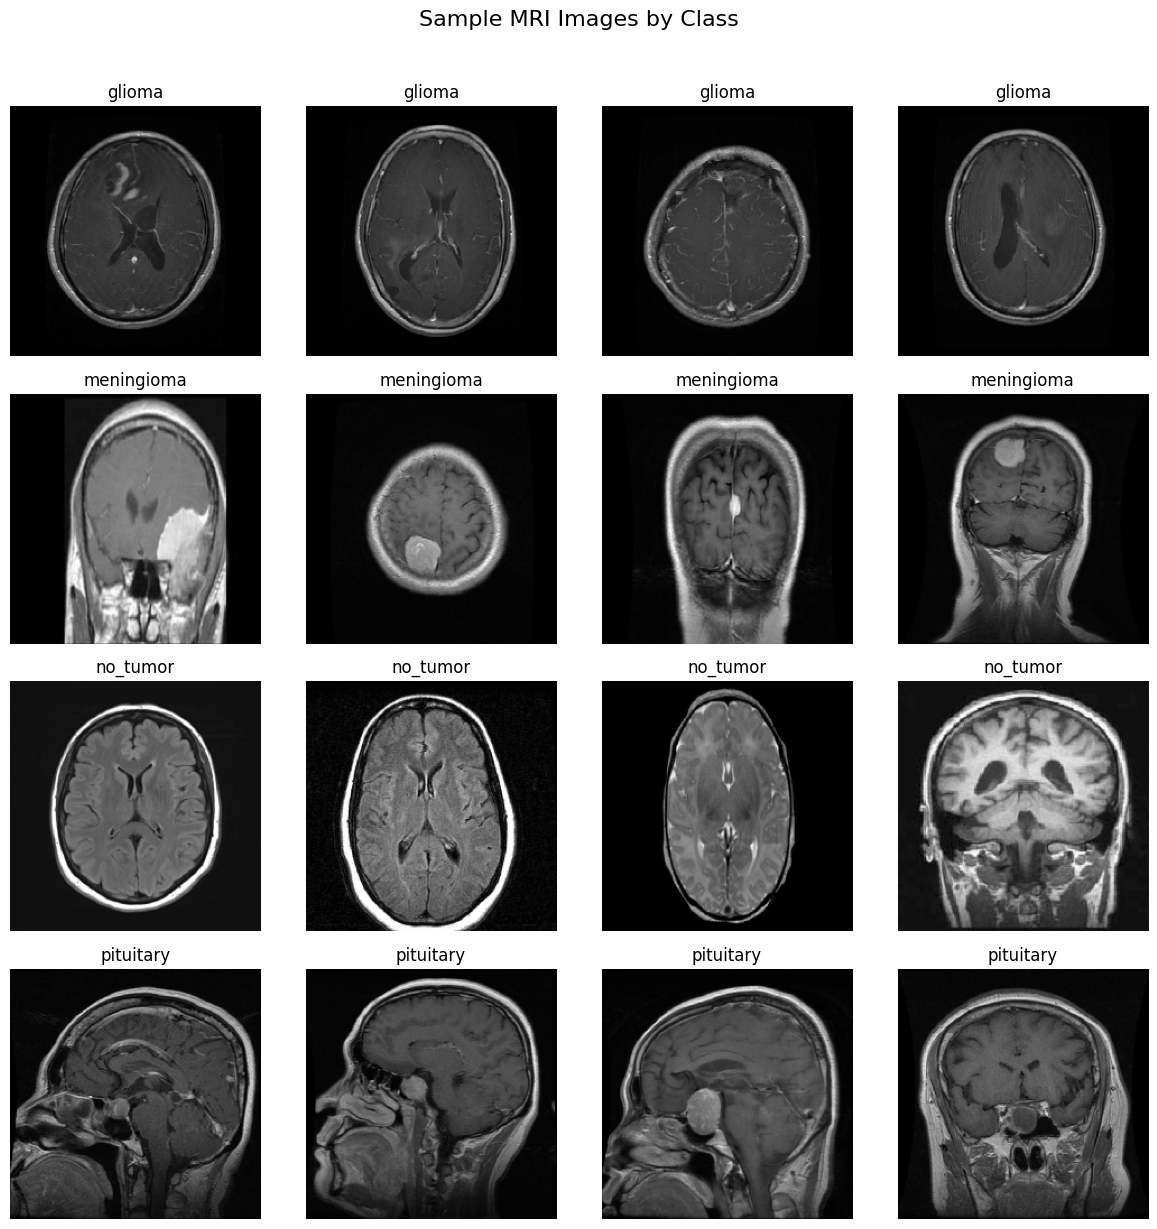

In [5]:
from tensorflow.keras.utils import load_img, img_to_array

CLASS_NAMES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
print("Classes:", CLASS_NAMES)

def get_image_paths(split_dir, class_name, n=4):
    paths = [p for p in (split_dir / class_name).rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    return paths[:n]

fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(12, 12))
for r, cls in enumerate(CLASS_NAMES):
    paths = get_image_paths(TRAIN_DIR, cls, 4)
    for c in range(4):
        ax = axes[r, c]
        if c < len(paths):
            img = load_img(paths[c], target_size=IMG_SIZE)
            ax.imshow(img)
            ax.set_title(cls)
        ax.axis("off")

plt.suptitle("Sample MRI Images by Class", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 6. Image-size and basic pixel audit

This gives a quick look at whether the source images have a consistent shape and how image intensity is distributed.

,Width,Height
count,300.0,300.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


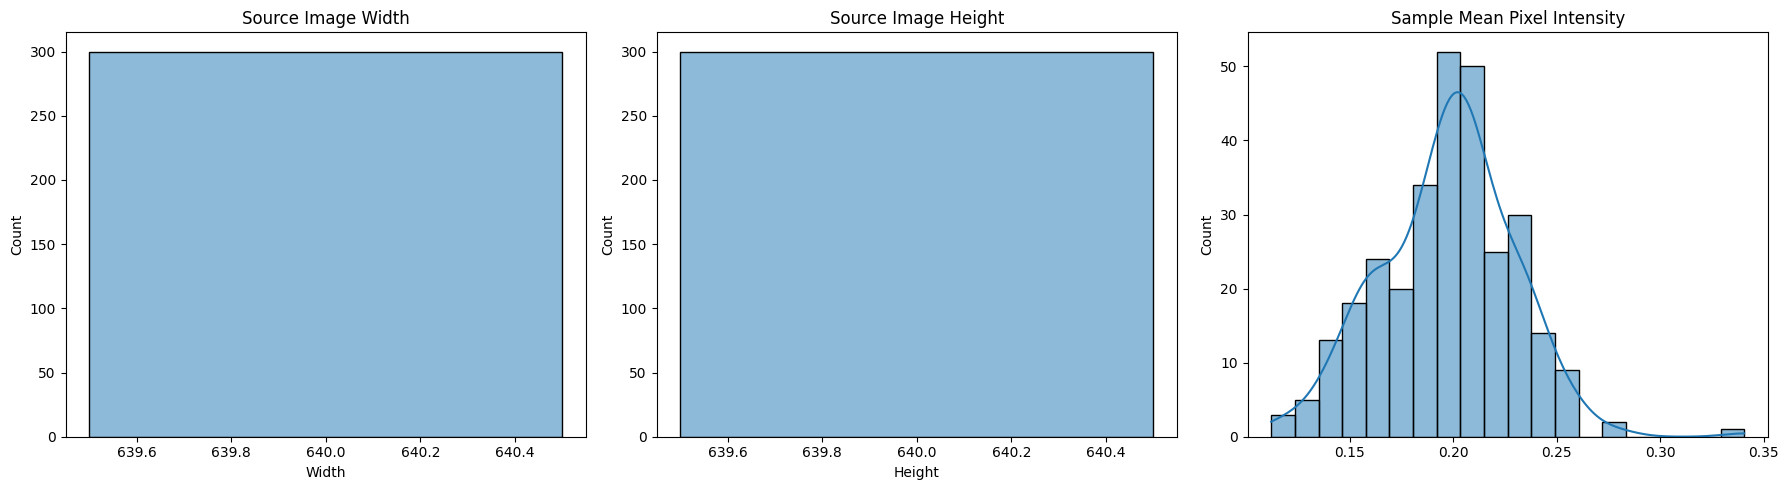

In [6]:
# Sample up to 300 images for a lightweight audit.
all_train_paths = [
    p for p in TRAIN_DIR.rglob("*")
    if p.suffix.lower() in IMAGE_EXTS
]
audit_paths = all_train_paths[:300]

sizes = []
pixel_means = []
pixel_stds = []

for p in audit_paths:
    try:
        img = load_img(p, color_mode="rgb")
        arr = img_to_array(img).astype(np.float32) / 255.0
        sizes.append(img.size)  # (width, height)
        pixel_means.append(arr.mean())
        pixel_stds.append(arr.std())
    except Exception:
        pass

size_df = pd.DataFrame(sizes, columns=["Width", "Height"])
display(size_df.describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(size_df["Width"], kde=True, ax=axes[0])
axes[0].set_title("Source Image Width")

sns.histplot(size_df["Height"], kde=True, ax=axes[1])
axes[1].set_title("Source Image Height")

sns.histplot(pixel_means, kde=True, ax=axes[2])
axes[2].set_title("Sample Mean Pixel Intensity")

plt.tight_layout()
plt.show()

## 7. Data loaders and augmentation

For training, moderate augmentation is used to improve generalization. Validation and test data are only rescaled.

The resize target is 224×224, matching the transfer-learning models used below.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


## 8. Visualize augmented images

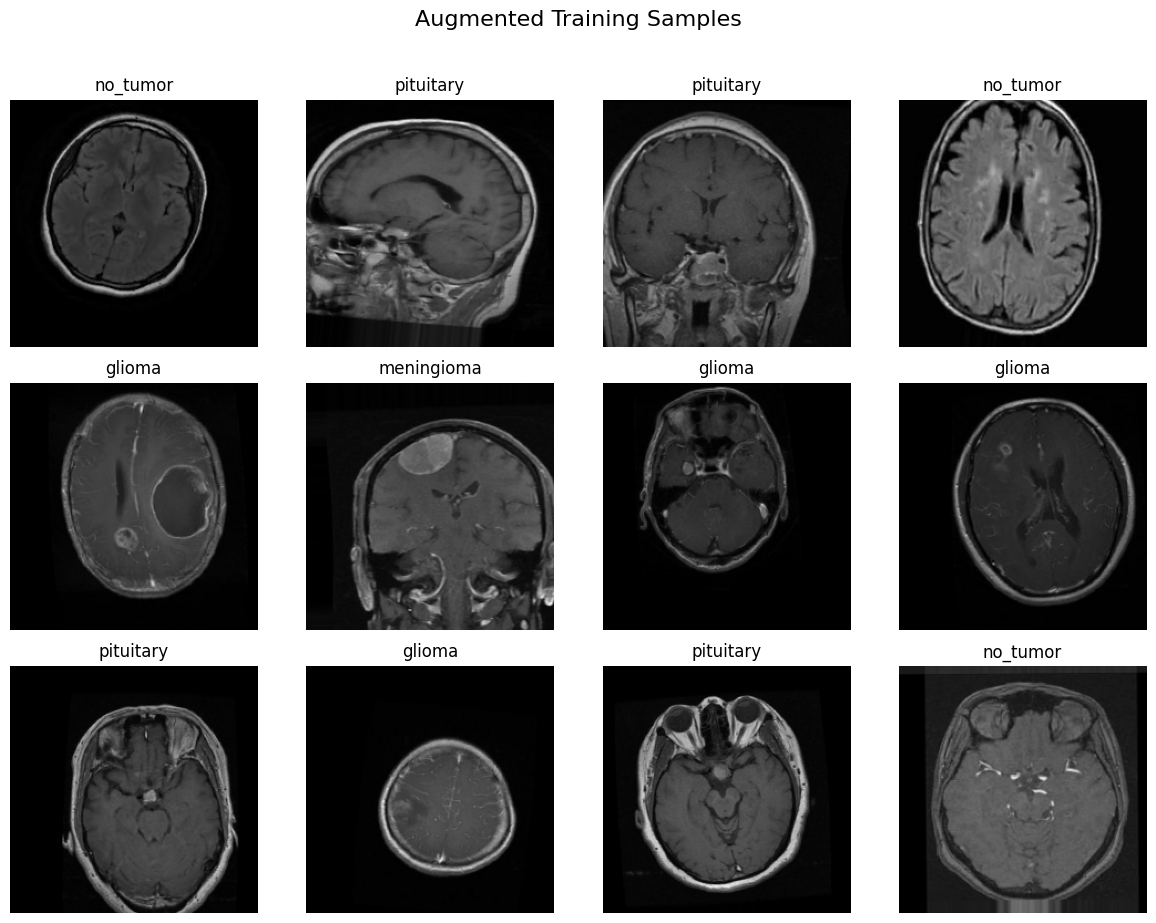

In [8]:
aug_images, aug_labels = next(train_generator)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(aug_images[i])
    ax.set_title(CLASS_NAMES[np.argmax(aug_labels[i])])
    ax.axis("off")

plt.suptitle("Augmented Training Samples", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 9. Class weights

The four classes are not perfectly balanced. Class weights make the loss pay somewhat more attention to less frequent classes without duplicating images.

In [9]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = train_generator.classes

class_ids = np.unique(y_train_labels)
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=y_train_labels
)

CLASS_WEIGHTS = {int(k): float(v) for k, v in zip(class_ids, weights)}
print(CLASS_WEIGHTS)

{0: 0.7513297872340425, 1: 1.183659217877095, 2: 1.2649253731343284, 3: 0.9674657534246576}


## 10. Custom CNN

This CNN is built from scratch with convolution, batch normalization, pooling, dropout and global average pooling.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers

custom_cnn = tf.keras.Sequential([
    
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(4, activation="softmax")
])

custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

print("Learning rate:",
      float(tf.keras.backend.get_value(custom_cnn.optimizer.learning_rate)))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Learning rate: 0.0010000000474974513


## 11. Callbacks and CNN training

In [11]:
import tensorflow as tf

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
cnn_callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_custom_cnn.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history_cnn = custom_cnn.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    class_weight=CLASS_WEIGHTS,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5726 - loss: 1.0899
Epoch 1: val_accuracy improved from None to 0.29880, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 226s 4s/step - accuracy: 0.6507 - loss: 0.8971 - val_accuracy: 0.2988 - val_loss: 1.6625 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7146 - loss: 0.7481
Epoch 2: val_accuracy improved from 0.29880 to 0.32072, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 216s 4s/step - accuracy: 0.7274 - loss: 0.7129 - val_accuracy: 0.3207 - val_loss: 2.6128 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7365 - loss: 0.6658
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_accuracy improved from 0.32072 to 0.32470, saving model to best_custom_cnn.keras



## 12. CNN training curves

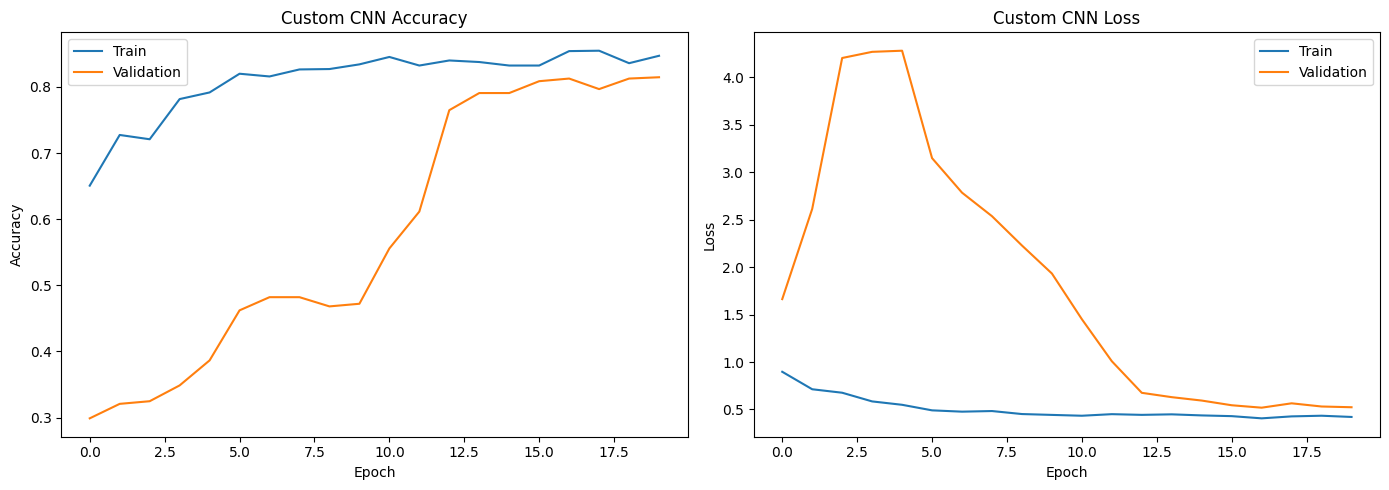

In [12]:
def plot_history(history, title_prefix="Model"):
    hist = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist["accuracy"], label="Train")
    axes[0].plot(hist["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title_prefix} Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(hist["loss"], label="Train")
    axes[1].plot(hist["val_loss"], label="Validation")
    axes[1].set_title(f"{title_prefix} Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Custom CNN")

## 13. Generic evaluation function

Accuracy alone is not enough for a multi-class medical-image classifier, so the notebook reports accuracy, macro precision, macro recall, macro F1, and the confusion matrix.

              precision    recall  f1-score   support

      glioma       0.95      0.90      0.92        80
  meningioma       0.82      0.51      0.63        63
    no_tumor       0.82      0.86      0.84        49
   pituitary       0.66      0.98      0.79        54

    accuracy                           0.81       246
   macro avg       0.81      0.81      0.80       246
weighted avg       0.83      0.81      0.80       246



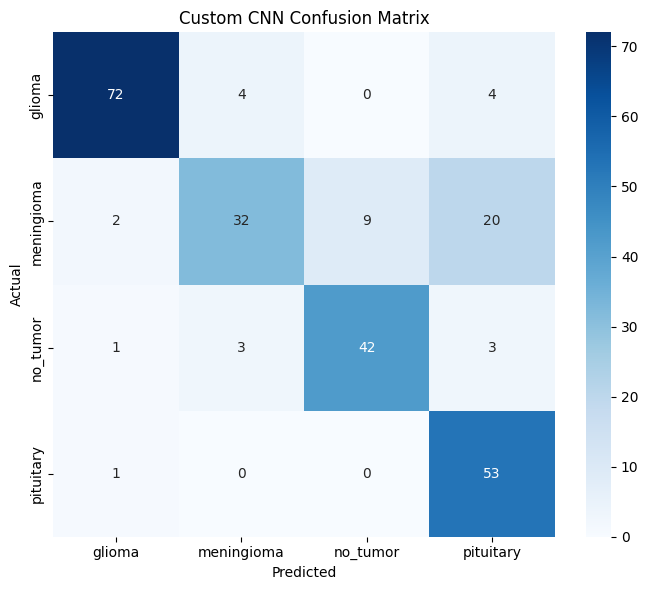

{'Model': 'Custom CNN',
 'Accuracy': 0.8089430894308943,
 'Precision_macro': 0.8134776633325395,
 'Recall_macro': 0.8116402116402116,
 'F1_macro': 0.7953931698971207}

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_classifier(model, generator, model_name, save_cm=True):
    generator.reset()
    probs = model.predict(generator, verbose=0)
    preds = np.argmax(probs, axis=1)
    true = generator.classes

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(true, preds),
        "Precision_macro": precision_score(true, preds, average="macro", zero_division=0),
        "Recall_macro": recall_score(true, preds, average="macro", zero_division=0),
        "F1_macro": f1_score(true, preds, average="macro", zero_division=0)
    }

    print(classification_report(
        true,
        preds,
        target_names=CLASS_NAMES,
        zero_division=0
    ))

    cm = confusion_matrix(true, preds)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return metrics, true, preds, probs

cnn_metrics, y_true_cnn, y_pred_cnn, cnn_probs = evaluate_classifier(
    custom_cnn,
    test_generator,
    "Custom CNN"
)

cnn_metrics

## 14. Transfer learning — EfficientNetB0

EfficientNetB0 is used first as the main transfer-learning model. The pretrained ImageNet feature extractor is frozen during the first stage and a new four-class classification head is trained.

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_eff.trainable = False

eff_inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_eff(eff_inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.50)(x)
eff_outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

efficientnet_model = tf.keras.Model(eff_inputs, eff_outputs)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 15. Train frozen EfficientNetB0

In [ ]:
eff_train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=(0.9, 1.1)
)

eff_valid_datagen = ImageDataGenerator()
eff_test_datagen = ImageDataGenerator()

eff_train_generator = eff_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

eff_valid_generator = eff_valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

eff_test_generator = eff_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers
import tensorflow as tf

base_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_eff.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_eff(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    4,
    activation="softmax"
)(x)

efficientnet_model = tf.keras.Model(
    inputs,
    outputs
)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(
    tf.keras.backend.get_value(
        efficientnet_model.optimizer.learning_rate
    )
)

0.001


In [ ]:
eff_callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_efficientnet_frozen.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history_eff_frozen = efficientnet_model.fit(
    eff_train_generator,
    validation_data=eff_valid_generator,
    epochs=10,
    callbacks=eff_callbacks,
    verbose=1
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6332 - loss: 0.8994
Epoch 1: val_accuracy improved from None to 0.77490, saving model to best_efficientnet_frozen.keras

Epoch 1: finished saving model to best_efficientnet_frozen.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7386 - loss: 0.6661 - val_accuracy: 0.7749 - val_loss: 0.5422 - learning_rate: 0.0010
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8473 - loss: 0.3987
Epoch 2: val_accuracy improved from 0.77490 to 0.82669, saving model to best_efficientnet_frozen.keras

Epoch 2: finished saving model to best_efficientnet_frozen.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8484 - loss: 0.3906 - val_accuracy: 0.8267 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8629 - loss: 0.3426
Epoch 3: val_accuracy improved from 0.82669 to 0.86454, saving model to best_efficientnet_frozen.keras

Epoch 3: finished saving model to

## 16. Fine-tune the upper EfficientNet layers

In [ ]:
for i, layer in enumerate(base_eff.layers):
    if layer.trainable:
        print(i, layer.name, type(layer).__name__)

print(
    "Learning rate:",
    float(tf.keras.backend.get_value(
        efficientnet_model.optimizer.learning_rate
    ))
)

Learning rate: 9.000000136438757e-05


In [ ]:
# Unfreeze the EfficientNet backbone
base_eff.trainable = True

# Freeze all but the last 30 layers
for layer in base_eff.layers[:-30]:
    layer.trainable = False

print("Trainable layers:",
      sum(layer.trainable for layer in base_eff.layers))
print("Total layers:",
      len(base_eff.layers))

# Recompile with a very small learning rate
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_efficientnet_finetuned.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

start = time.time()

history_eff_finetune = efficientnet_model.fit(
    eff_train_generator,
    validation_data=eff_valid_generator,
    epochs=12,
    callbacks=fine_callbacks,
    verbose=1
)

print(f"Fine-tuning time: {(time.time()-start)/60:.2f} minutes")

Trainable layers: 30
Total layers: 238
Epoch 1/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7456 - loss: 0.6780
Epoch 1: val_accuracy improved from None to 0.87251, saving model to best_efficientnet_finetuned.keras

Epoch 1: finished saving model to best_efficientnet_finetuned.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7699 - loss: 0.6043 - val_accuracy: 0.8725 - val_loss: 0.3373 - learning_rate: 1.0000e-05
Epoch 2/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8235 - loss: 0.5031
Epoch 2: val_accuracy improved from 0.87251 to 0.87450, saving model to best_efficientnet_finetuned.keras

Epoch 2: finished saving model to best_efficientnet_finetuned.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.8437 - loss: 0.4562 - val_accuracy: 0.8745 - val_loss: 0.3580 - learning_rate: 1.0000e-05
Epoch 3/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8685 - loss: 0.3785
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.


## 17. EfficientNet learning curves

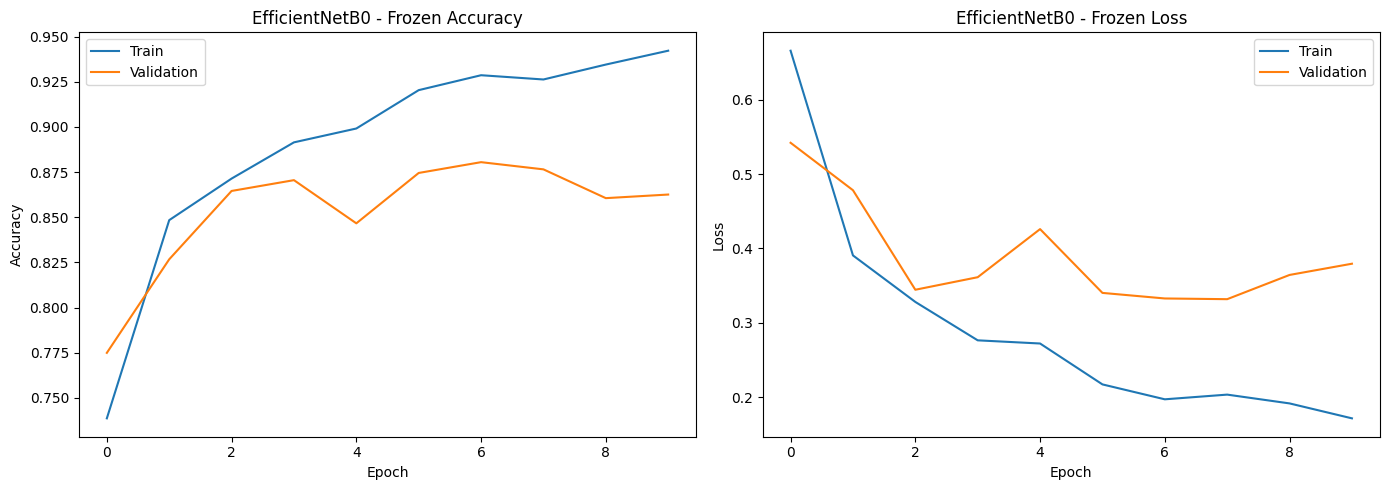

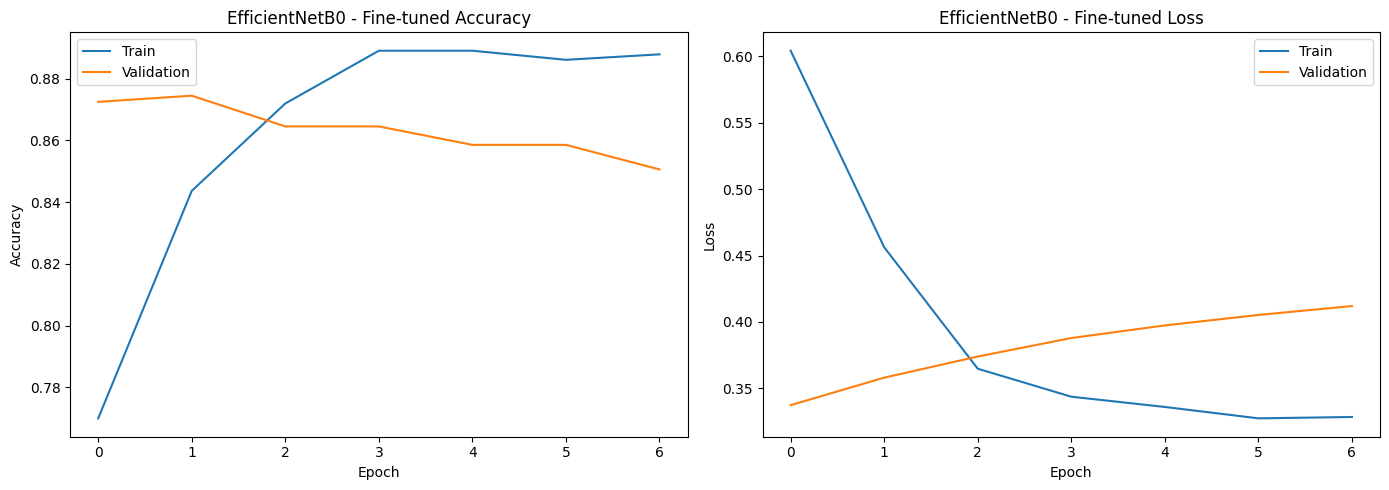

In [ ]:
plot_history(history_eff_frozen, "EfficientNetB0 - Frozen")
plot_history(history_eff_finetune, "EfficientNetB0 - Fine-tuned")

## 18. Optional second transfer-learning model — ResNet50

This cell is intentionally optional because ResNet50 adds training time. Run it when you have enough GPU time and want a stronger model-comparison section.

In [ ]:
RUN_RESNET = False

if RUN_RESNET:
    from tensorflow.keras.applications import ResNet50

    base_resnet = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_resnet.trainable = False

    res_inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_resnet(res_inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.50)(x)
    res_outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    resnet_model = tf.keras.Model(res_inputs, res_outputs)

    resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    res_callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
        ModelCheckpoint("best_resnet50.keras", monitor="val_accuracy", save_best_only=True)
    ]

    history_resnet = resnet_model.fit(
        train_generator,
        validation_data=valid_generator,
        epochs=10,
        class_weight=CLASS_WEIGHTS,
        callbacks=res_callbacks,
        verbose=1
    )
else:
    print("RUN_RESNET=False — skipping ResNet50 training.")

RUN_RESNET=False — skipping ResNet50 training.


## 19. Evaluate transfer-learning models

              precision    recall  f1-score   support

      glioma       0.33      1.00      0.49        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.33       246
   macro avg       0.08      0.25      0.12       246
weighted avg       0.11      0.33      0.16       246



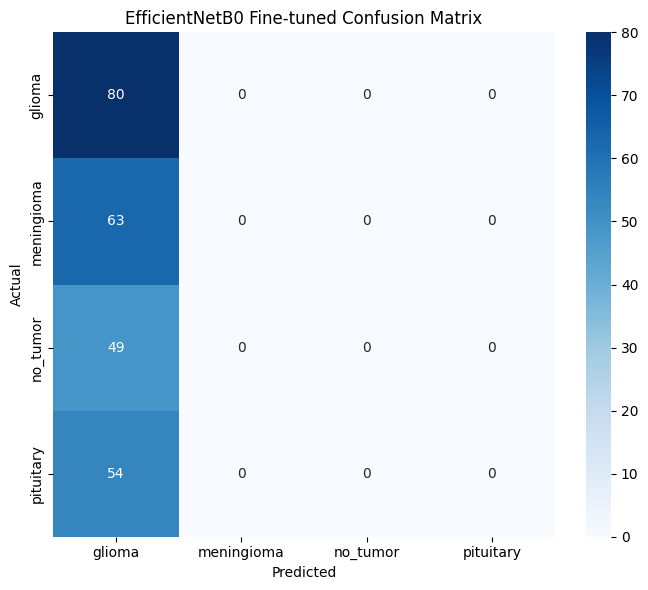

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Custom CNN,0.808943,0.813478,0.81164,0.795393
1,EfficientNetB0 Fine-tuned,0.325203,0.081301,0.25000,0.122699


In [ ]:
eff_metrics, y_true_eff, y_pred_eff, eff_probs = evaluate_classifier(
    efficientnet_model,
    test_generator,
    "EfficientNetB0 Fine-tuned"
)

metrics_rows = [cnn_metrics, eff_metrics]

if RUN_RESNET:
    res_metrics, y_true_res, y_pred_res, res_probs = evaluate_classifier(
        resnet_model,
        test_generator,
        "ResNet50"
    )
    metrics_rows.append(res_metrics)

comparison_df = pd.DataFrame(metrics_rows).sort_values("F1_macro", ascending=False).reset_index(drop=True)
display(comparison_df)

## 20. Model comparison plots

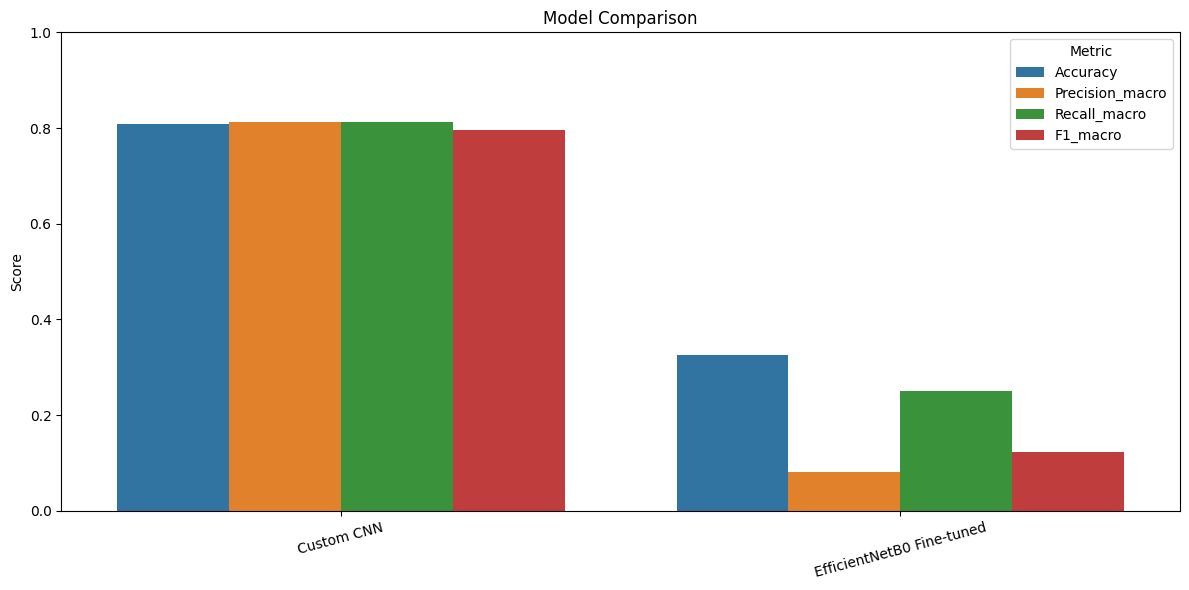

In [ ]:
plot_metrics = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_metrics, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.xlabel("")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 21. Detailed per-class performance

Macro metrics can hide class-specific weaknesses. The next cell prints a detailed classification report for the chosen final model.

              precision    recall  f1-score   support

      glioma       0.33      1.00      0.49        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.33       246
   macro avg       0.08      0.25      0.12       246
weighted avg       0.11      0.33      0.16       246



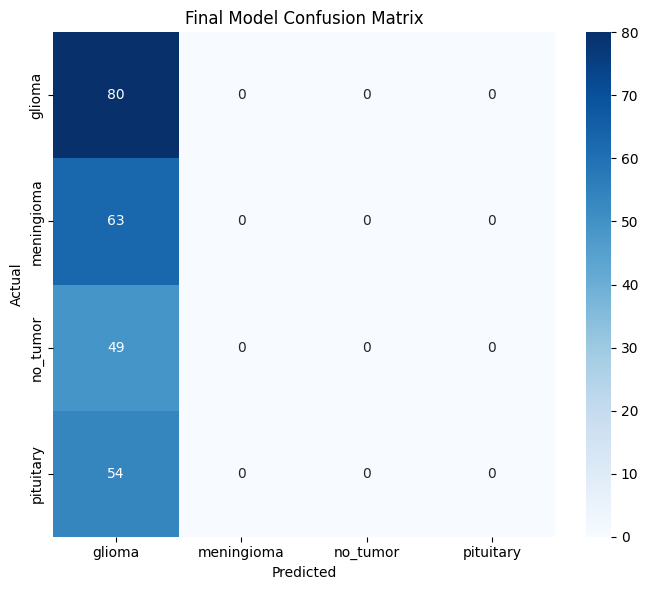

In [ ]:
FINAL_MODEL = efficientnet_model

final_metrics, final_true, final_pred, final_probs = evaluate_classifier(
    FINAL_MODEL,
    test_generator,
    "Final Model"
)

## 22. Prediction confidence analysis

This shows the distribution of the model's maximum softmax confidence. High confidence is not the same as clinical certainty; it is simply the model's output confidence.

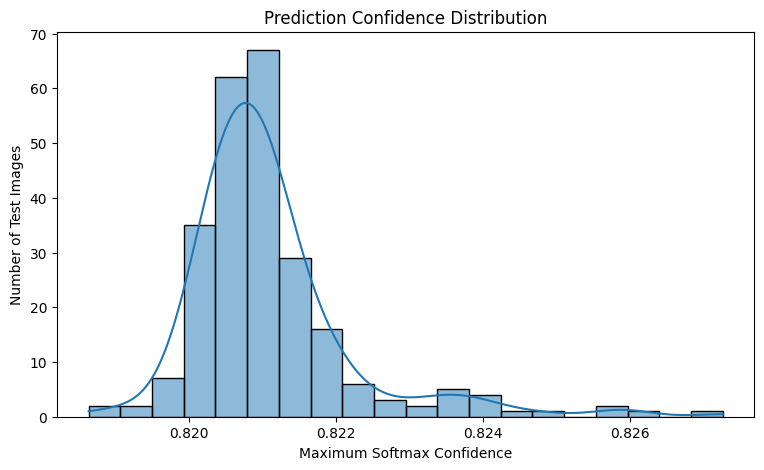

Mean confidence: 0.8211027
Median confidence: 0.8208871


In [ ]:
confidence = final_probs.max(axis=1)

plt.figure(figsize=(9, 5))
sns.histplot(confidence, bins=20, kde=True)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Maximum Softmax Confidence")
plt.ylabel("Number of Test Images")
plt.show()

print("Mean confidence:", confidence.mean())
print("Median confidence:", np.median(confidence))

## 23. Error analysis

We inspect the most uncertain test examples and the examples where the prediction disagrees with the true label.

In [ ]:
test_paths = test_generator.filepaths
error_df = pd.DataFrame({
    "path": test_paths,
    "true": [CLASS_NAMES[i] for i in final_true],
    "pred": [CLASS_NAMES[i] for i in final_pred],
    "confidence": confidence
})

error_df["correct"] = error_df["true"] == error_df["pred"]
error_df["error_score"] = 1 - error_df["confidence"]

display(error_df.sort_values("error_score", ascending=False).head(15))

,path,true,pred,confidence,correct,error_score
192,/kaggle/input/datasets/sonug2527/brain-tumor-m...,pituitary,glioma,0.818637,False,0.181363
184,/kaggle/input/datasets/sonug2527/brain-tumor-m...,no_tumor,glioma,0.818976,False,0.181024
113,/kaggle/input/datasets/sonug2527/brain-tumor-m...,meningioma,glioma,0.819269,False,0.180731
100,/kaggle/input/datasets/sonug2527/brain-tumor-m...,meningioma,glioma,0.819326,False,0.180674
160,/kaggle/input/datasets/sonug2527/brain-tumor-m...,no_tumor,glioma,0.819670,False,0.180330
219,/kaggle/input/datasets/sonug2527/brain-tumor-m...,pituitary,glioma,0.819715,False,0.180285
232,/kaggle/input/datasets/sonug2527/brain-tumor-m...,pituitary,glioma,0.819801,False,0.180199
165,/kaggle/input/datasets/sonug2527/brain-tumor-m...,no_tumor,glioma,0.819852,False,0.180148
177,/kaggle/input/datasets/sonug2527/brain-tumor-m...,no_tumor,glioma,0.819875,False,0.180125
157,/kaggle/input/datasets/sonug2527/brain-tumor-m...,no_tumor,glioma,0.819887,False,0.180113


## 24. Visualize incorrect predictions

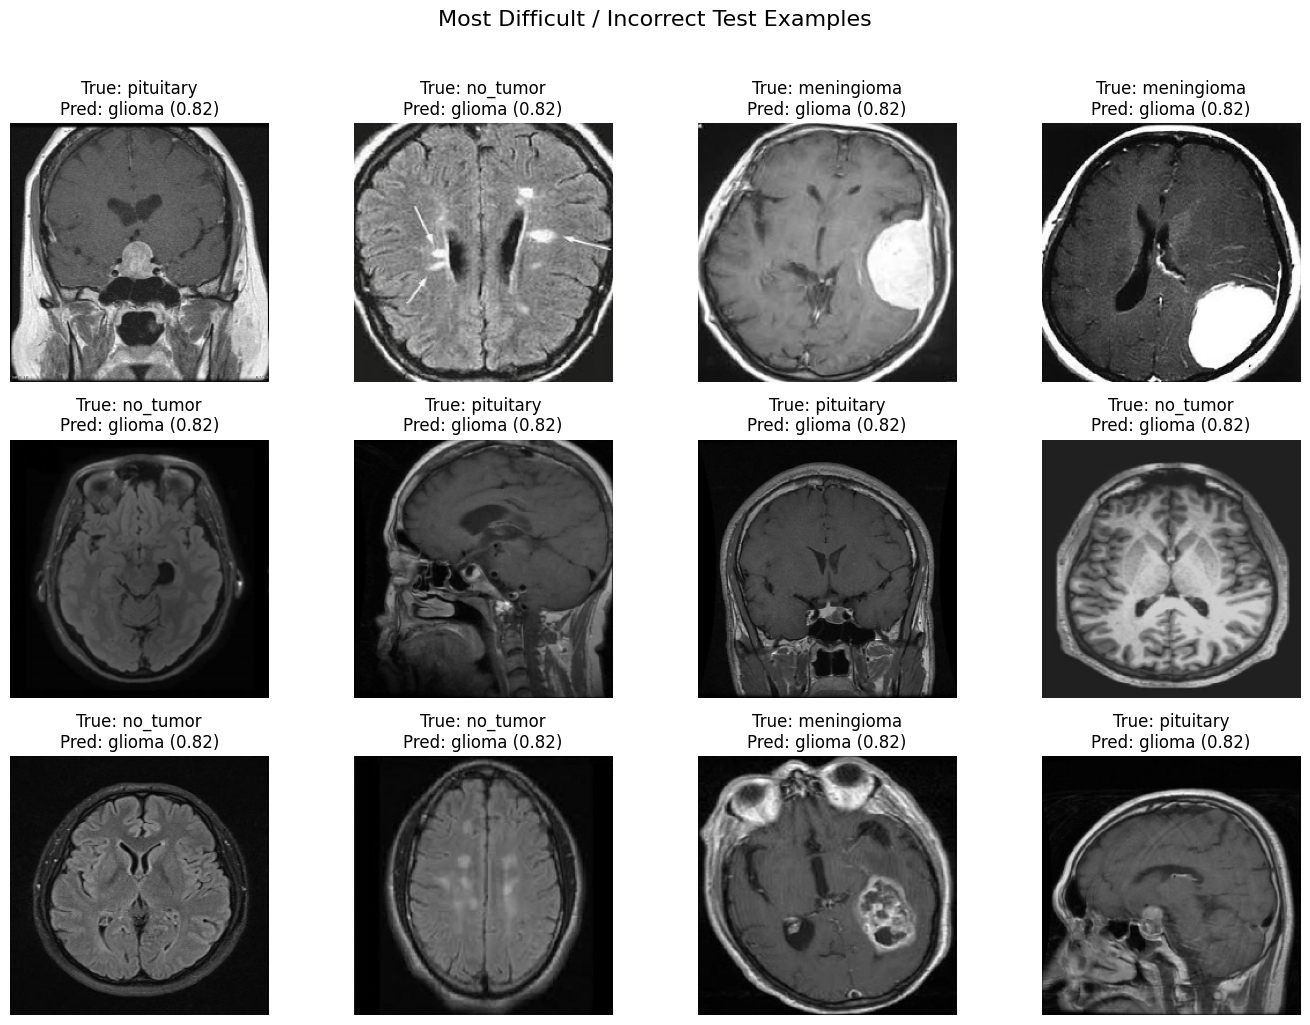

In [ ]:
wrong = error_df[~error_df["correct"]].sort_values("error_score", ascending=False).head(12)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, (_, row) in zip(axes.flat, wrong.iterrows()):
    img = load_img(row["path"], target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title(
        f"True: {row['true']}\nPred: {row['pred']} ({row['confidence']:.2f})"
    )
    ax.axis("off")

for ax in axes.flat[len(wrong):]:
    ax.axis("off")

plt.suptitle("Most Difficult / Incorrect Test Examples", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 25. Grad-CAM explainability

Grad-CAM highlights image regions that contribute strongly to a class prediction. It is an interpretability aid, not proof that the highlighted region is medically meaningful.

In [ ]:
def find_last_conv_layer(model):
    # Search from the end for the last 4D convolution-like layer.
    for layer in reversed(model.layers):
        if isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D, layers.SeparableConv2D)):
            return layer.name
    # For nested backbones, search common backbone layer names.
    for layer in reversed(model.layers):
        try:
            shape = layer.output.shape
            if len(shape) == 4:
                return layer.name
        except Exception:
            pass
    raise ValueError("No suitable convolutional layer found.")

LAST_CONV_LAYER = find_last_conv_layer(FINAL_MODEL)
print("Grad-CAM layer:", LAST_CONV_LAYER)

Grad-CAM layer: efficientnetb0


Final Model: functional_2
EfficientNet Backbone: efficientnetb0
Backbone output shape: (None, 7, 7, 1280)

Testing image:
/kaggle/input/datasets/sonug2527/brain-tumor-mri/Tumour-20260930T062410Z-1-001/Tumour/test/glioma/Tr-gl_0016_jpg.rf.99746694ea97fe0b73108832b462d48e.jpg

Image information:
Shape: (224, 224, 3)
Min: 0.0
Max: 240.0
Mean: 33.629524
Std: 40.87566

Grad-CAM layer: top_conv
Layer output: (None, 7, 7, 1280)


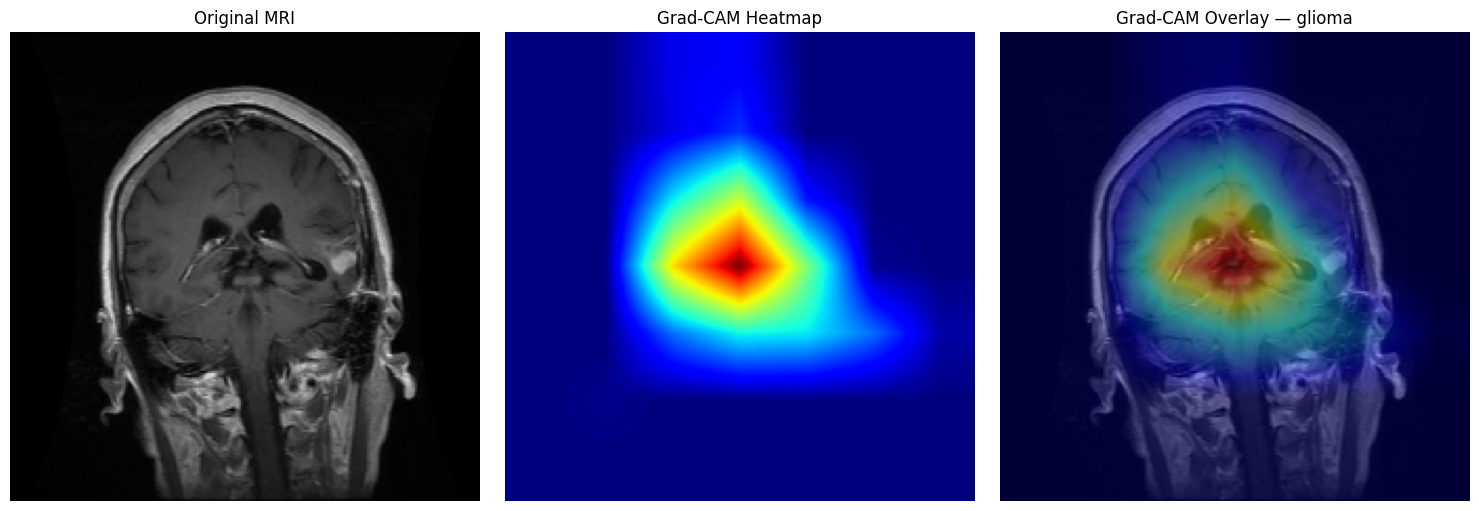

In [ ]:
# ============================================================
# GRAD-CAM FOR EFFICIENTNET
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array


# ------------------------------------------------------------
# 1. FIND EFFICIENTNET BACKBONE
# ------------------------------------------------------------

BACKBONE = None

for i, layer in enumerate(FINAL_MODEL.layers):
    if isinstance(layer, tf.keras.Model):
        BACKBONE = layer
        BACKBONE_INDEX = i
        break

print("Final Model:", FINAL_MODEL.name)
print("EfficientNet Backbone:", BACKBONE.name if BACKBONE else "NOT FOUND")

if BACKBONE is None:
    raise ValueError(
        "EfficientNet backbone was not found inside FINAL_MODEL."
    )

print("Backbone output shape:", BACKBONE.output_shape)


# ------------------------------------------------------------
# 2. PREPARE IMAGE
# ------------------------------------------------------------

def prepare_image(path):

    img = load_img(
        path,
        target_size=IMG_SIZE,
        color_mode="rgb"
    )

    arr = img_to_array(img).astype(np.float32)

    print("\nImage information:")
    print("Shape:", arr.shape)
    print("Min:", arr.min())
    print("Max:", arr.max())
    print("Mean:", arr.mean())
    print("Std:", arr.std())

    if arr.max() == 0:
        raise ValueError(
            "The image contains only zeros. Check the image path/dataset."
        )

    batch = np.expand_dims(arr, axis=0)

    return img, batch


# ------------------------------------------------------------
# 3. GRAD-CAM
# ------------------------------------------------------------

def make_gradcam_heatmap(
    img_array,
    model,
    backbone,
    pred_index=None
):

    # Find last convolutional layer
    target_layer = None

    for layer in reversed(backbone.layers):

        if isinstance(
            layer,
            (
                tf.keras.layers.Conv2D,
                tf.keras.layers.DepthwiseConv2D
            )
        ):
            target_layer = layer
            break

    if target_layer is None:
        raise ValueError(
            "Could not find a convolutional layer."
        )

    print("\nGrad-CAM layer:", target_layer.name)
    print("Layer output:", target_layer.output.shape)

    # Model that gives convolutional feature maps
    feature_extractor = tf.keras.Model(
        inputs=backbone.input,
        outputs=target_layer.output
    )

    img_array = tf.cast(
        img_array,
        tf.float32
    )

    with tf.GradientTape() as tape:

        # Get convolutional features
        conv_outputs = feature_extractor(
            img_array,
            training=False
        )

        # Pass through remaining classification layers
        x = conv_outputs

        for layer in model.layers[BACKBONE_INDEX + 1:]:
            x = layer(
                x,
                training=False
            )

        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[:, pred_index]

    # Calculate gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    # Create heatmap
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Remove negative values
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy(), int(pred_index)


# ------------------------------------------------------------
# 4. CREATE OVERLAY
# ------------------------------------------------------------

def overlay_gradcam(
    path,
    model,
    backbone,
    alpha=0.4
):

    original, batch = prepare_image(path)

    heatmap, pred_index = make_gradcam_heatmap(
        batch,
        model,
        backbone
    )

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (IMG_SIZE[1], IMG_SIZE[0])
    )

    # Convert to 0-255
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    # Color heatmap
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Original image
    original_rgb = np.array(
        original.convert("RGB")
    )

    # Overlay
    overlay = np.clip(
        alpha * heatmap_color
        + (1 - alpha) * original_rgb,
        0,
        255
    ).astype(np.uint8)

    pred_class = CLASS_NAMES[pred_index]

    return (
        original_rgb,
        heatmap_resized,
        overlay,
        pred_class
    )


# ------------------------------------------------------------
# 5. RUN GRAD-CAM
# ------------------------------------------------------------

example_path = test_paths[0]

print("\nTesting image:")
print(example_path)

orig, heat, overlay, pred_class = overlay_gradcam(
    example_path,
    FINAL_MODEL,
    BACKBONE
)


# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(orig)
axes[0].set_title("Original MRI")
axes[0].axis("off")

axes[1].imshow(
    heat,
    cmap="jet"
)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(
    f"Grad-CAM Overlay — {pred_class}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 26. Save the final model


In [ ]:
FINAL_MODEL_PATH = "/kaggle/working/brain_tumor_efficientnet_final.keras"
FINAL_MODEL.save(FINAL_MODEL_PATH)

CLASS_MAP_PATH = "/kaggle/working/class_names.json"
with open(CLASS_MAP_PATH, "w") as f:
    json.dump(CLASS_NAMES, f)

print("Saved model:", FINAL_MODEL_PATH)
print("Saved classes:", CLASS_MAP_PATH)

Saved model: /kaggle/working/brain_tumor_efficientnet_final.keras
Saved classes: /kaggle/working/class_names.json
